The code below is generated using Chatgpt, based on the paper `Spatio-temporal prediction model of out-of- hospital cardiac arrest: Designation of medical priorities and estimation of human resources requirement`

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

In [3]:
import os

parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
# print(parent_dir)

import synthetic data

In [10]:
map_file_path = "/SpatioTemporal_prediction/synthetic_data/municipal_shape.shp"
swiss_ticino_map = parent_dir + map_file_path

swiss_ticino_gdf = gpd.read_file(swiss_ticino_map)
print(swiss_ticino_gdf.crs)

COMPD_CS["CH1903+ / LV95 + LN02 height",PROJCS["CH1903+ / LV95",GEOGCS["CH1903+",DATUM["CH1903+",SPHEROID["Bessel 1841",6377397.155,299.1528128,AUTHORITY["EPSG","7004"]],AUTHORITY["EPSG","6150"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4150"]],PROJECTION["Hotine_Oblique_Mercator_Azimuth_Center"],PARAMETER["latitude_of_center",46.9524055555556],PARAMETER["longitude_of_center",7.43958333333333],PARAMETER["azimuth",90],PARAMETER["rectified_grid_angle",90],PARAMETER["scale_factor",1],PARAMETER["false_easting",2600000],PARAMETER["false_northing",1200000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","2056"]],VERT_CS["LN02 height",VERT_DATUM["Landesnivellement 1902",2005,AUTHORITY["EPSG","5127"]],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Gravity-related height",UP],AUTHORITY["EPSG","5728"]]]


/Users/yitong/opt/anaconda3/envs/geopandasNew/lib/python3.9/site-packages/pyogrio/geopandas.py:265: UserWarning: More than one layer found in 'municipal_shape.shp': 'swissBOUNDARIES3D_1_5_TLM_BEZIRKSGEBIET' (default), 'swissBOUNDARIES3D_1_5_TLM_HOHEITSGRENZE', 'swissBOUNDARIES3D_1_5_TLM_KANTONSGEBIET', 'swissBOUNDARIES3D_1_5_TLM_LANDESGEBIET', 'swissBOUNDARIES3D_1_5_TLM_HOHEITSGEBIET'. Specify layer parameter to avoid this warning.
  result = read_func(


<Axes: >

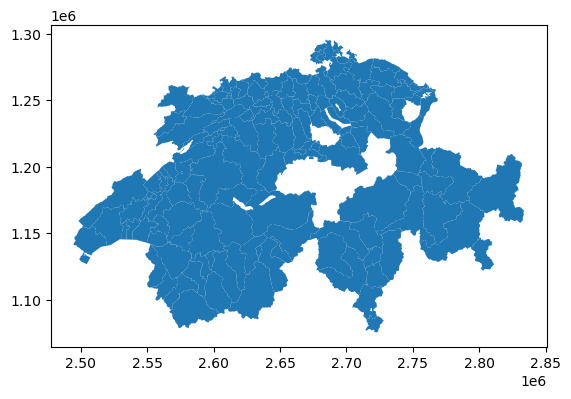

In [13]:
swiss_ticino_gdf.plot()

In [ ]:
# INLA-like spatio-temporal scaffolding for OHCA prediction on synthetic Ticino data in Python
# Using PyMC for Bayesian modeling as INLA is not available in Python
# Author: ChatGPT

import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

# ========================
# 1️⃣ Load your synthetic OHCA data
# ========================
ohca_df = pd.read_csv("synthetic_ohca_ticino_2016_2019.csv")
ohca_df['municipality_id'] = ohca_df['municipality'].astype('category').cat.codes
ohca_df['year_id'] = ohca_df['year'] - ohca_df['year'].min()

# ========================
# 2️⃣ Prepare the model data
# ========================
n_municipalities = ohca_df['municipality_id'].nunique()
n_years = ohca_df['year_id'].nunique()

population_scaled = ohca_df['population'] / 1000
ohca_counts = ohca_df['ohca_count'].values
municipality_idx = ohca_df['municipality_id'].values
year_idx = ohca_df['year_id'].values

# ========================
# 3️⃣ Define the PyMC spatio-temporal model (BYM approximation)
# ========================
with pm.Model() as model:
    # Global intercept
    alpha = pm.Normal('alpha', mu=0, sigma=10)
    
    # Municipality-level random effects
    sigma_space = pm.Exponential('sigma_space', 1)
    space_effect = pm.Normal('space_effect', mu=0, sigma=sigma_space, shape=n_municipalities)

    # Year-level random effects
    sigma_time = pm.Exponential('sigma_time', 1)
    time_effect = pm.GaussianRandomWalk('time_effect', sigma=sigma_time, shape=n_years)

    # Expected log rates
    mu = alpha + space_effect[municipality_idx] + time_effect[year_idx] + np.log(population_scaled)

    # Likelihood
    y_obs = pm.Poisson('y_obs', mu=pm.math.exp(mu), observed=ohca_counts)
    
    # Sampling
    trace = pm.sample(2000, tune=1000, target_accept=0.95, cores=4, random_seed=42)

# ========================
# 4️⃣ Posterior analysis
# ========================
az.plot_trace(trace, var_names=['alpha', 'sigma_space', 'sigma_time'])
plt.show()

summary = az.summary(trace, var_names=['alpha', 'sigma_space', 'sigma_time'])
print(summary)

# ========================
# 5️⃣ Posterior predictive check and fitted rates
# ========================
with model:
    posterior_predictive = pm.sample_posterior_predictive(trace)

ohca_df['fitted_mean'] = posterior_predictive['y_obs'].mean(axis=0)
ohca_df['fitted_lower'] = np.percentile(posterior_predictive['y_obs'], 2.5, axis=0)
ohca_df['fitted_upper'] = np.percentile(posterior_predictive['y_obs'], 97.5, axis=0)

# ========================
# 6️⃣ Visualization
# ========================
plt.figure(figsize=(10,6))
plt.hist(ohca_df['fitted_mean'], bins=30, color='skyblue', edgecolor='black')
plt.title('Fitted OHCA Counts Distribution')
plt.xlabel('Fitted OHCA Count')
plt.ylabel('Frequency')
plt.show()

# ========================
# Next steps for your pipeline:
# ========================
# ✅ Integrate your shapefile using geopandas for mapping
# ✅ Plot municipality-level predicted incidence with credible intervals
# ✅ Use for AED optimization and forecasting extensions for 2020-2023
# ✅ Integrate with interactive dashboards if desired using Plotly or Streamlit
